# **Detection of Cardiac Abnormalities from Multilead ECG**

In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.1 MB/s eta 0:00:00


# Libraries

In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
import pywt
from scipy.signal import butter, filtfilt, hilbert
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
from scipy.stats import gaussian_kde
from sklearn.feature_selection import f_classif
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Load the data , and labelling them

In [3]:
dataset_path = '/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0'

records = []
labels  = []

# Map from PTB comment keywords → class label
# Order matters: check more specific strings first
LABEL_MAP = [
    ("myocardial infarction", "MI"),
    ("bundle branch block",   "BBB"),
    ("cardiomyopathy",        "HMD"),   # 13 cardiomyopathy subjects
    ("hypertrophy",           "HMD"),   # 7 hypertrophy subjects  ← FIX: was missing
    ("healthy control",       "HC"),
]

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if not file.endswith(".hea"):
            continue

        record_path = os.path.join(root, file[:-4])
        try:
            header   = wfdb.rdheader(record_path)
            comments = " ".join(header.comments).lower()

            label = None
            for keyword, cls in LABEL_MAP:
                if keyword in comments:
                    label = cls
                    break       # stop at first match

            if label is not None:
                records.append(record_path)
                labels.append(label)

        except Exception:
            pass

df_records = pd.DataFrame({"record_path": records, "label": labels})
df_records.to_csv("ptb_labels_fixed.csv", index=False)

print("=== Records per class ===")
print(df_records["label"].value_counts())
print(f"\nTotal records: {len(df_records)}")

=== Records per class ===
label
MI     368
HC      80
HMD     23
BBB     20
Name: count, dtype: int64

Total records: 491


# Preprocessing

## Load single ECG for better visualization


In [4]:
import wfdb
import numpy as np

# record path
record = wfdb.rdrecord('/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0/patient001/s0010_re')

signal = record.p_signal
fs = record.fs

# Extract first 12 leads only
ecg_12 = signal[:, 0:12]

print("Shape of ECG:", ecg_12.shape)
print("Sampling frequency:", fs)

Shape of ECG: (38400, 12)
Sampling frequency: 1000


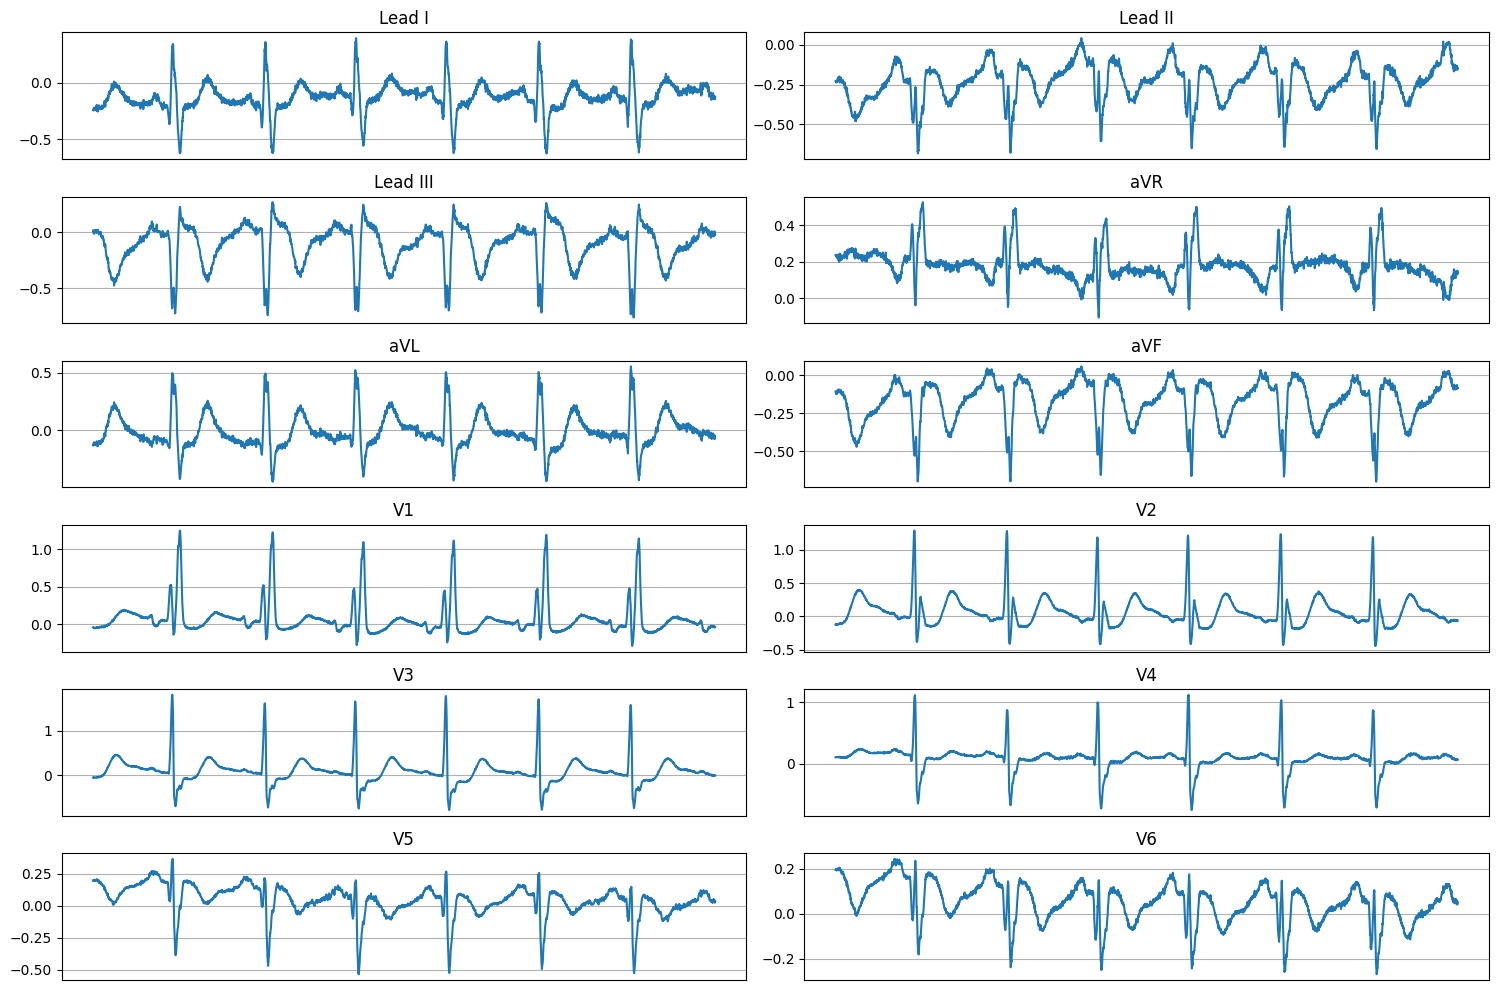

In [5]:
import matplotlib.pyplot as plt

# Standard 12-lead names
lead_names = [
    "Lead I", "Lead II", "Lead III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]

plt.figure(figsize=(15,10))

for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(ecg_12[:5*fs, i])
    plt.title(lead_names[i])
    plt.xticks([])
    plt.grid(True)

plt.tight_layout()
plt.show()

## Applying Butterwoth filter (Cutoff frequency =0.5 hz)

In [6]:
def butter_highpass(signal_1d, fs, cutoff=0.5, order=4):
    """Zero-phase Butterworth high-pass filter (removes baseline wander)."""
    nyquist = 0.5 * fs
    b, a = butter(order, cutoff / nyquist, btype='high', analog=False)
    return filtfilt(b, a, signal_1d)

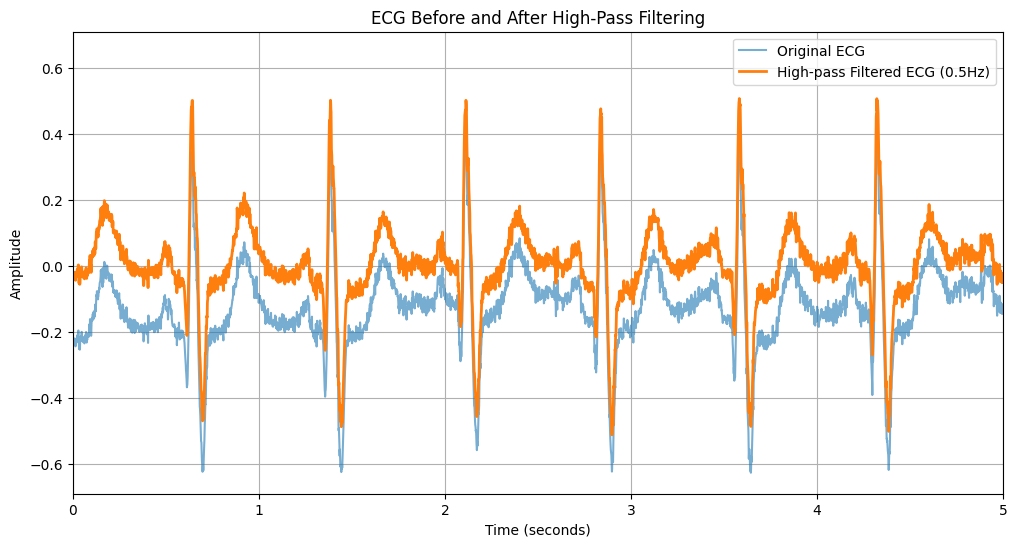

In [7]:
import matplotlib.pyplot as plt

# take one ECG lead

lead_signal = ecg_12[:, 0]   # Lead I
fs = 1000  

# Apply filter

filtered_signal = butter_highpass(lead_signal, fs)

# Create time axis

t = np.arange(len(lead_signal)) / fs

# Plot

plt.figure(figsize=(12,6))
plt.plot(t, lead_signal, label="Original ECG", alpha=0.6)
plt.plot(t, filtered_signal, label="High-pass Filtered ECG (0.5Hz)", linewidth=2)

plt.xlim(0,5)   # Show first 5 seconds
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Before and After High-Pass Filtering")
plt.legend()
plt.grid(True)
plt.show()

## Wavelet denoising

In [8]:


def wavelet_denoise(signal_1d, wavelet='db4', level=5):
    
    " Wavelet soft-thresholding to remove high-frequency noise."
    
    coeffs   = pywt.wavedec(signal_1d, wavelet, level=level)
    sigma    = np.median(np.abs(coeffs[-1])) / 0.6745
    thresh   = sigma * np.sqrt(2 * np.log(len(signal_1d)))
    new_coeffs = [coeffs[0]] + [pywt.threshold(c, thresh, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(new_coeffs, wavelet)[:len(signal_1d)]

def preprocess_record(signal_2d, fs, n_leads=12):
    
    """
    Apply HPF + wavelet denoising to each of the first 12 leads.

    FIX 1d: PTB records have 15 channels (12 standard + vx,vy,vz).
             The paper uses 12 leads only, so we slice [:, :12].
    """
    
    sig = signal_2d[:, :n_leads].copy()    # keep only 12 leads
    out = np.zeros_like(sig)
    for lead in range(n_leads):
        filtered  = butter_highpass(sig[:, lead], fs)
        denoised  = wavelet_denoise(filtered)
        out[:, lead] = denoised
    return out

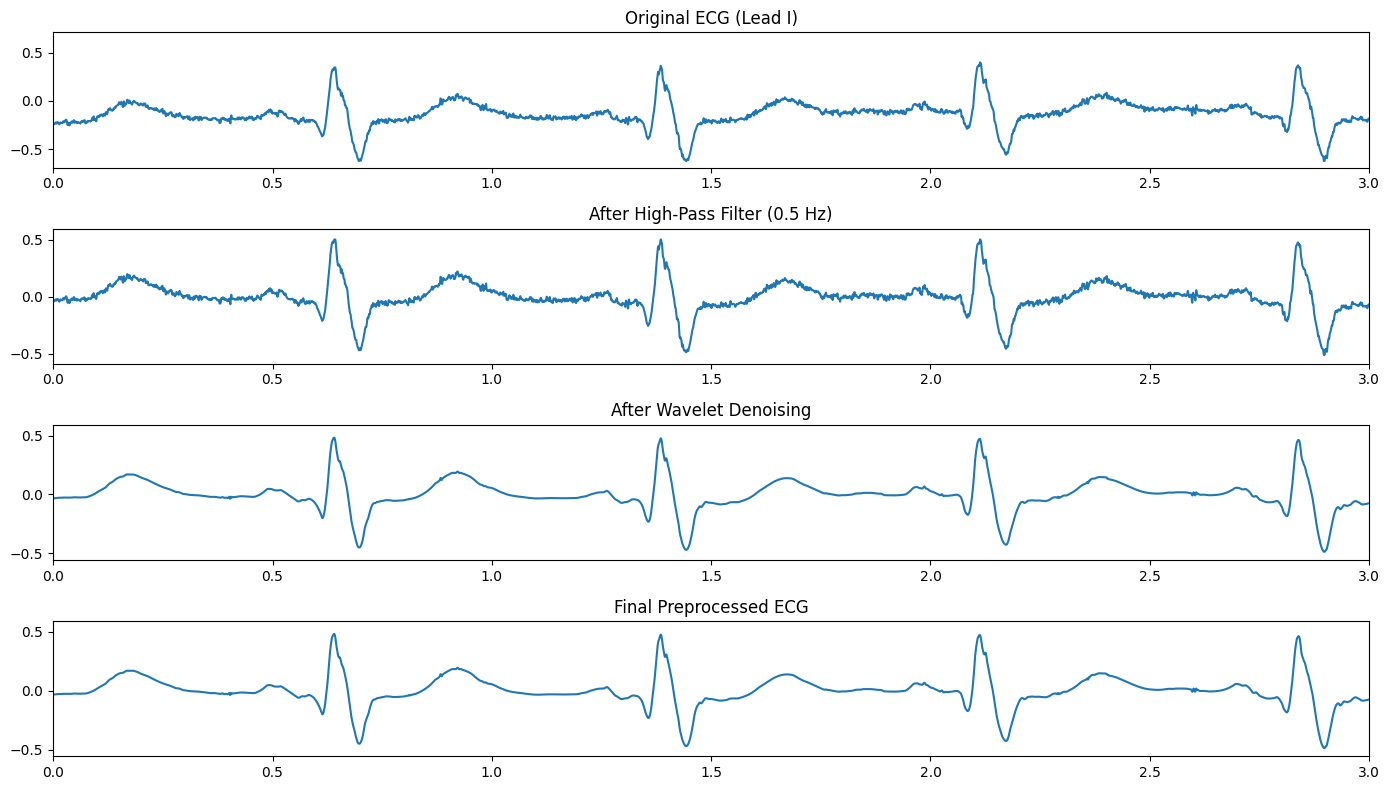

In [9]:
import numpy as np

# Choose one lead (Lead I)
lead = 0
raw_signal = signal[:, lead]              # original PTB signal
hpf_signal = butter_highpass(raw_signal, fs)
den_signal = wavelet_denoise(hpf_signal)
final_signal = preprocess_record(signal, fs)[:, lead]

# Time axis (first 5 seconds for clarity)
t = np.arange(len(raw_signal)) / fs

plt.figure(figsize=(14,8))

plt.subplot(4,1,1)
plt.plot(t, raw_signal)
plt.title("Original ECG (Lead I)")
plt.xlim(0,3)

plt.subplot(4,1,2)
plt.plot(t, hpf_signal)
plt.title("After High-Pass Filter (0.5 Hz)")
plt.xlim(0,3)

plt.subplot(4,1,3)
plt.plot(t, den_signal)
plt.title("After Wavelet Denoising")
plt.xlim(0,3)

plt.subplot(4,1,4)
plt.plot(t, final_signal)
plt.title("Final Preprocessed ECG")
plt.xlim(0,3)

plt.tight_layout()
plt.show()

## Creating Non overlapping Frames

In [10]:

def create_frames(signal_2d, frame_size=4096):
    """Split a record into non-overlapping 4096-sample frames (paper: 4096×12)."""
    n_samples = signal_2d.shape[0]
    n_frames  = n_samples // frame_size
    frames = []
    for i in range(n_frames):
        frames.append(signal_2d[i*frame_size : (i+1)*frame_size, :])
    return frames

In [11]:
clean_ecg = preprocess_record(signal, fs)

frames = create_frames(clean_ecg, frame_size=4096)

print("Number of frames:", len(frames))
print("Shape of one frame:", frames[0].shape)

Number of frames: 9
Shape of one frame: (4096, 12)


In [12]:
# checking frames are overlapping or not

print(np.all(frames[0][-1] == frames[1][0]))

False


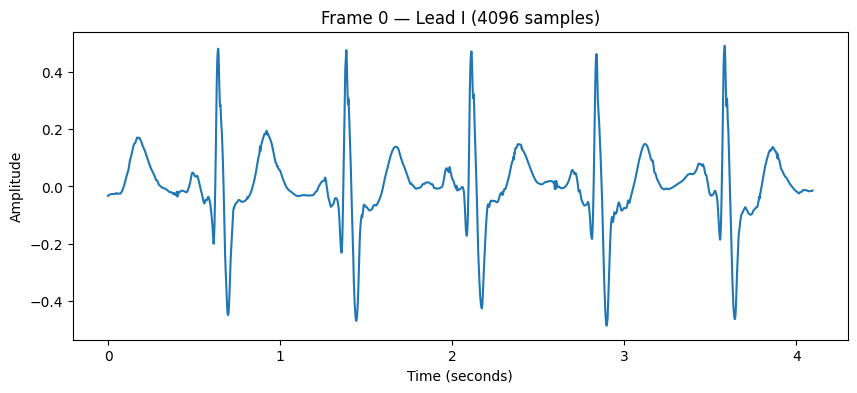

In [13]:
# Pltting 1 frame 

import matplotlib.pyplot as plt
import numpy as np

frame0 = frames[0]

t = np.arange(4096) / fs

plt.figure(figsize=(10,4))
plt.plot(t, frame0[:,0])   # Lead I
plt.title("Frame 0 — Lead I (4096 samples)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

# Phase Alternation Feature Extraction

In [14]:
# Evalution of multiscale PA features

def phase_alternation(phase_seq):
    """
    Count sign alternations in a phase sequence.
    PA = number of positions where consecutive phase values have opposite signs
    (i.e. phase[i]/phase[i+1] < 0).
    """
    phase1 = phase_seq[:-1]
    phase2 = phase_seq[1:]
    eps    = 1e-10
    phase2 = np.where(phase2 == 0, eps, phase2)
    return int(np.sum(phase1 / phase2 < 0))

def extract_pa_features_from_frame(frame, n_leads=12, wavelet='db4', level=6):
    """
    Extract 48-dimensional PA feature vector from one frame (4096 × 12).

    For each lead: DWT → cA6, cD6, cD5, cD4
                   Hilbert → phase
                   PA count per sub-band
    12 leads × 4 sub-bands = 48 features
    """
    features = []
    for lead in range(n_leads):
        coeffs = pywt.wavedec(frame[:, lead], wavelet, level=level)
        cA6, cD6, cD5, cD4 = coeffs[0], coeffs[1], coeffs[2], coeffs[3]

        for subband in [cA6, cD6, cD5, cD4]:
            phase = np.angle(hilbert(subband))                 # Hilbert transform shift the signal by +_90 , convert to analytic signal (x1 + jx2) 
            features.append(phase_alternation(phase))

    return features   # length = 48


In [15]:
# printing all the 48 feature vector that was extracted from dwt+hilbert transform

from scipy.signal import hilbert

frame0 = frames[0]

features = extract_pa_features_from_frame(frame0)

print("Feature length:", len(features))
print("Feature vector:\n", features)

Feature length: 48
Feature vector:
 [34, 53, 105, 229, 22, 43, 100, 212, 22, 59, 99, 152, 35, 49, 95, 231, 28, 59, 107, 171, 22, 57, 71, 178, 26, 34, 119, 218, 22, 21, 115, 241, 30, 49, 125, 249, 44, 51, 125, 243, 26, 55, 126, 218, 22, 35, 115, 204]


## Plotting Phase subband(cD4, cD5, cD6,cA6)

cA6 PA count: 34
cD6 PA count: 53
cD5 PA count: 105
cD4 PA count: 229


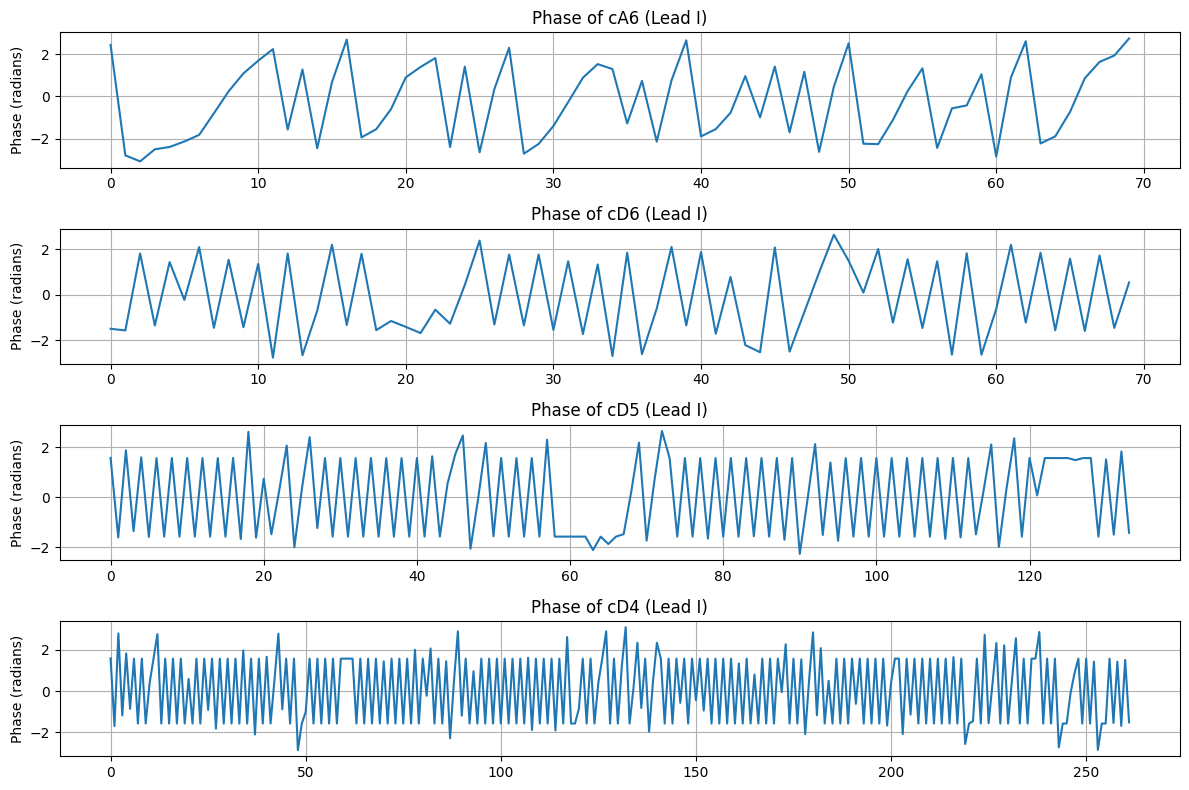

In [16]:
# plotting 
from scipy.signal import hilbert
import pywt

lead = 0
coeffs = pywt.wavedec(frame0[:, lead], 'db4', level=6)

# Extract required subbands
cA6 = coeffs[0]
cD6 = coeffs[1]
cD5 = coeffs[2]
cD4 = coeffs[3]

subbands = {
    "cA6": cA6,
    "cD6": cD6,
    "cD5": cD5,
    "cD4": cD4
}

plt.figure(figsize=(12,8))

for i, (name, band) in enumerate(subbands.items(), 1):
    analytic = hilbert(band)
    phase = np.angle(analytic)

    plt.subplot(4,1,i)
    plt.plot(phase)
    plt.title(f"Phase of {name} (Lead I)")
    plt.ylabel("Phase (radians)")
    plt.grid(True)

    print(f"{name} PA count:", phase_alternation(phase))

plt.tight_layout()
plt.show()

In [17]:
all_features = []

for frame in frames:
    f = extract_pa_features_from_frame(frame)
    all_features.append(f)

all_features = np.array(all_features)

print("Feature matrix shape:", all_features.shape)

Feature matrix shape: (9, 48)


# Build Feature matrix X and Label vector Y

In [18]:
X_list = []
y_list = []
failed = 0

print("\n=== Extracting features from all records ===")

for idx, row in df_records.iterrows():
    record_path = row["record_path"]
    label       = row["label"]

    try:
        rec    = wfdb.rdrecord(record_path)
        sig    = rec.p_signal   # shape (n_samples, 15)
        fs     = rec.fs

        # Preprocess (filter + denoise, keep 12 leads)
        sig_clean = preprocess_record(sig, fs, n_leads=12)

        # Split into 4096-sample frames
        frames = create_frames(sig_clean, frame_size=4096)

        for frame in frames:
            features = extract_pa_features_from_frame(frame, n_leads=12)
            X_list.append(features)
            y_list.append(label)           # ← label comes from the RECORD, not frame index

    except Exception as e:
        failed += 1
        # Uncomment to debug individual failures:
        # print(f"  Failed {record_path}: {e}")
        continue

    # Progress every 50 records
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx+1}/{len(df_records)} records...")

X = np.array(X_list, dtype=float)
y = np.array(y_list)

print(f"\n=== Feature matrix built ===")
print(f"X shape : {X.shape}   (frames × 48 features)")
print(f"y shape : {y.shape}")
print(f"Failed records : {failed}")
print(f"\nClass distribution in y:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls}: {cnt} frames")


=== Extracting features from all records ===
  Processed 50/491 records...
  Processed 100/491 records...
  Processed 150/491 records...
  Processed 200/491 records...
  Processed 250/491 records...
  Processed 300/491 records...
  Processed 350/491 records...
  Processed 400/491 records...
  Processed 450/491 records...

=== Feature matrix built ===
X shape : (13451, 48)   (frames × 48 features)
y shape : (13451,)
Failed records : 0

Class distribution in y:
  BBB: 551 frames
  HC: 2285 frames
  HMD: 623 frames
  MI: 9992 frames


# Normalize features (paper uses Min-Max normalization)

In [19]:
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nX_scaled range: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print("✓ Features normalized to [0, 1] — matches paper Tables 1–4")


X_scaled range: [0.000, 1.000]
✓ Features normalized to [0, 1] — matches paper Tables 1–4


# labels: HC=1 MI=2 HMD=3 BBB=4

In [20]:
# Paper: HC=1, MI=2, HMD=3, BBB=4

LABEL_ENCODE = {"HC": 1, "MI": 2, "HMD": 3, "BBB": 4}
LABEL_DECODE = {v: k for k, v in LABEL_ENCODE.items()}

y_int = np.array([LABEL_ENCODE[cls] for cls in y])

print(f"\ny_int unique values: {np.unique(y_int)}")
print("Label encoding:", LABEL_ENCODE)
print("\n✓ X_scaled and y_int are ready for feature selection + classification")

# Save for use in next cells
np.save("X_scaled.npy", X_scaled)
np.save("y_int.npy",    y_int)
print("\n✓ Saved X_scaled.npy and y_int.npy")


y_int unique values: [1 2 3 4]
Label encoding: {'HC': 1, 'MI': 2, 'HMD': 3, 'BBB': 4}

✓ X_scaled and y_int are ready for feature selection + classification

✓ Saved X_scaled.npy and y_int.npy


# Load Extracted Data

In [21]:
X_scaled = np.load("X_scaled.npy")   # shape (N, 48), min-max normalised to [0,1]
y_int    = np.load("y_int.npy")      # int labels: HC=1 MI=2 HMD=3 BBB=4

# Paper uses these 12 standard leads and 4 sub-bands
LEADS    = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
SUBBANDS = ["cA6","cD6","cD5","cD4"]
CLASSES  = {1:"HC", 2:"MI", 3:"HMD", 4:"BBB"}

print("=== Data loaded ===")
print(f"X shape : {X_scaled.shape}")
unique, counts = np.unique(y_int, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CLASSES[u]:4} : {c} frames")

=== Data loaded ===
X shape : (13451, 48)
  HC   : 2285 frames
  MI   : 9992 frames
  HMD  : 623 frames
  BBB  : 551 frames


# Tables 1–4: μ and σ of normalised PA features

In [22]:
print("\n" + "="*60)
print("μ and σ of Normalised PA Features")
print("="*60)

for sb_idx, subband in enumerate(SUBBANDS):

    print(f"\n{subband} Sub-band")
    print("-"*60)
    print(f"{'Class':6} {'Type':6} " + " ".join(f"{l:>7}" for l in LEADS))

    # feature indices for this subband (same for all classes)
    fidx = [lead * 4 + sb_idx for lead in range(12)]

    for cls_int, cls_name in CLASSES.items():

        X_sub = X_scaled[y_int == cls_int][:, fidx]

        mu    = X_sub.mean(axis=0)
        sigma = X_sub.std(axis=0)

        print(f"{cls_name:6} Mean   " + " ".join(f"{v:7.3f}" for v in mu))
        print(f"{cls_name:6} Std    " + " ".join(f"{v:7.3f}" for v in sigma))


μ and σ of Normalised PA Features

cA6 Sub-band
------------------------------------------------------------
Class  Type         I      II     III     aVR     aVL     aVF      V1      V2      V3      V4      V5      V6
HC     Mean     0.394   0.456   0.524   0.423   0.415   0.500   0.548   0.357   0.363   0.346   0.413   0.434
HC     Std      0.133   0.123   0.141   0.114   0.139   0.128   0.139   0.139   0.124   0.125   0.116   0.123
MI     Mean     0.468   0.461   0.470   0.470   0.421   0.459   0.479   0.397   0.425   0.417   0.476   0.482
MI     Std      0.160   0.147   0.151   0.143   0.153   0.146   0.151   0.154   0.154   0.146   0.153   0.167
HMD    Mean     0.477   0.448   0.471   0.445   0.385   0.468   0.491   0.407   0.423   0.433   0.499   0.474
HMD    Std      0.177   0.158   0.145   0.155   0.165   0.132   0.154   0.146   0.173   0.169   0.174   0.169
BBB    Mean     0.360   0.432   0.445   0.422   0.358   0.449   0.428   0.322   0.330   0.355   0.428   0.388
BBB    Std

# Computing SD Score

In [23]:
def compute_sd_score(X, y, Q=12):
    """
    Statistical Dependency score (Eq. 3).
    Quantises each feature into Q bins, then computes the mutual
    information-like score between feature and class label.
    """
    n_samples, n_features = X.shape
    sd_scores = np.zeros(n_features)
    total     = n_samples
    Py_counts = Counter(y)

    for r in range(n_features):
        feat = X[:, r]
        # Quantise into Q bins
        bins = np.linspace(feat.min(), feat.max(), Q)
        z_r  = np.digitize(feat, bins)
        Pz_counts = Counter(z_r)

        score = 0.0
        for i in range(total):
            P_zy = np.sum((z_r == z_r[i]) & (y == y[i])) / total
            Pz   = Pz_counts[z_r[i]] / total
            Py   = Py_counts[y[i]] / total
            if Pz * Py > 0:
                score += abs(P_zy - Pz * Py)

        sd_scores[r] = score

    return sd_scores

# Table 5: SD scores + ANOVA p-values

In [24]:
print("\n" + "="*75)
print("TABLE 5: SD scores and ANOVA p-values for all 48 PA features")
print("="*75)
print("Computing SD scores (may take 2–3 min on full dataset)...")

sd_scores          = compute_sd_score(X_scaled, y_int, Q=12)
F_scores, p_values = f_classif(X_scaled, y_int)

# Reshape into (4 subbands × 12 leads) grids for display
sd_grid = np.array([[sd_scores[lead*4 + sb] for lead in range(12)] for sb in range(4)])
pv_grid = np.array([[p_values[lead*4  + sb] for lead in range(12)] for sb in range(4)])

hdr = f"{'Sub-band':8} " + "".join(f"{l:8}" for l in LEADS)

print("\nSD Scores  (threshold > 0.035 → selected):")
print(hdr)
for sb_idx, sb in enumerate(SUBBANDS):
    vals = "".join(f"{v:8.4f}" for v in sd_grid[sb_idx])
    print(f"SD{sb:5} {vals}")

print("\nANOVA p-values  (threshold < 0.001 → selected):")
print(hdr)
for sb_idx, sb in enumerate(SUBBANDS):
    vals = "".join(f"{'<0.001':>8}" if v < 0.001 else f"{v:8.4f}"
                   for v in pv_grid[sb_idx])
    print(f"p {sb:6} {vals}")


TABLE 5: SD scores and ANOVA p-values for all 48 PA features
Computing SD scores (may take 2–3 min on full dataset)...

SD Scores  (threshold > 0.035 → selected):
Sub-band I       II      III     aVR     aVL     aVF     V1      V2      V3      V4      V5      V6      
SDcA6   128.6280 60.3728 49.6219 85.3599 50.0292 90.9989 75.7906 94.4268150.9672116.9820 93.7253 95.4144
SDcD6    51.2183 38.5709 28.5248 30.1608 50.5925 25.9933 73.6194 66.8989 81.4891 66.5414 29.5968 29.5667
SDcD5    56.5933106.9510 47.4243108.8830 53.0733 80.8080 77.1280108.5362113.1562 48.7027 48.3819 34.9777
SDcD4    23.9286148.2140107.4877116.0497 45.1492150.6965141.6700 61.1495 34.5011126.8847224.7770221.7909

ANOVA p-values  (threshold < 0.001 → selected):
Sub-band I       II      III     aVR     aVL     aVF     V1      V2      V3      V4      V5      V6      
p cA6      <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001  <0.001
p cD6      <0.001  <0.001  <0.001  <0.001  <0.001

# Feature Selection

In [25]:
#Feature selection
# ANOVA keeps features with p < 0.001 → ~44 features
# SD score keeps features with SD > 0.035 → ~40 features

In [26]:
sel_anova = np.where(p_values < 0.001)[0]
sel_sd    = np.where(sd_scores > 0.035)[0]

X_all   = X_scaled
X_anova = X_scaled[:, sel_anova]
X_sd    = X_scaled[:, sel_sd]

print(f"\nAll features  : {X_all.shape[1]:3d}  (paper: 48)")
print(f"ANOVA selected: {X_anova.shape[1]:3d}  (paper: 44)")
print(f"SD selected   : {X_sd.shape[1]:3d}  (paper: 40)")


All features  :  48  (paper: 48)
ANOVA selected:  47  (paper: 44)
SD selected   :  48  (paper: 40)


# Fuzzy KNN classifier 

In [27]:
class FuzzyKNN:
    """
    Fuzzy K-Nearest Neighbor classifier.
    Class membership = fraction of K neighbours belonging to each class.
    Predicts the class with highest membership.
    """
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train  = X
        self.y_train  = y
        self.classes_ = np.unique(y)   # fixed class set from training data

    def predict(self, X):
        preds = []
        for x in X:
            dists  = np.linalg.norm(self.X_train - x, axis=1)
            nn_idx = np.argsort(dists)[:self.k]
            nn_lbl = self.y_train[nn_idx]
            # Membership = fraction of neighbours per class
            memb   = {c: np.sum(nn_lbl == c) / self.k for c in self.classes_}
            preds.append(max(memb, key=memb.get))
        return np.array(preds)

## 5-fold cross-validation

In [28]:
def evaluate(X_in, y_in, clf_type='fuzzy_knn', k=5):
    """5-fold CV. Returns per-class sensitivity and overall accuracy."""
    kf        = KFold(n_splits=5, shuffle=True, random_state=42)
    cls_labels = [1, 2, 3, 4]
    all_sens   = []

    for tr_idx, te_idx in kf.split(X_in):
        X_tr, X_te = X_in[tr_idx], X_in[te_idx]
        y_tr, y_te = y_in[tr_idx], y_in[te_idx]

        if clf_type == 'fuzzy_knn':
            clf = FuzzyKNN(k=k)
        else:
            clf = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)

        # FIX: pass integer labels explicitly — matches y_int dtype
        cm  = confusion_matrix(y_te, y_pred, labels=cls_labels)
        rs  = cm.sum(axis=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            sens = np.where(rs > 0, cm.diagonal() / rs, 0.0)
        all_sens.append(sens)

    mean_s = np.mean(all_sens, axis=0)
    return mean_s, mean_s.mean()


print("\n" + "="*75)
print("TABLE 6: Classifier performance (5-fold CV, K=5, paper values for reference)")
print("="*75)
print("Running evaluations…")

configs = [
    ("All features",         X_all,    "fuzzy_knn", "Fuzzy KNN"),
    ("Selected (ANOVA)",     X_anova,  "fuzzy_knn", "Fuzzy KNN"),
    ("Selected (SD score)",  X_sd,     "fuzzy_knn", "Fuzzy KNN"),
    ("All features",         X_all,    "knn",       "KNN"),
    ("Selected (ANOVA)",     X_anova,  "knn",       "KNN"),
    ("Selected (SD score)",  X_sd,     "knn",       "KNN"),
]

table6_rows = []
for feat_name, X_in, clf_type, clf_label in configs:
    sens, acc = evaluate(X_in, y_int, clf_type=clf_type, k=5)
    table6_rows.append({
        "Feature selection": feat_name,
        "Classifier":        clf_label,
        "HC %":    round(sens[0]*100, 2),
        "MI %":    round(sens[1]*100, 2),
        "HMD %":   round(sens[2]*100, 2),
        "BBB %":   round(sens[3]*100, 2),
        "Accuracy %": round(acc*100, 2),
    })
    print(f"  {clf_label:10} | {feat_name:22} → Acc={acc*100:.2f}%  "
          f"HC={sens[0]*100:.1f}% MI={sens[1]*100:.1f}% "
          f"HMD={sens[2]*100:.1f}% BBB={sens[3]*100:.1f}%")

df_t6 = pd.DataFrame(table6_rows)
print("\n", df_t6.to_string(index=False))

# Paper reference values (Table 6):
paper_ref = """
 Paper Table 6 (expected):
  Fuzzy KNN | All features         → Acc=84.96%  HC=89.46% MI=94.60% HMD=78.86% BBB=78.41%
  Fuzzy KNN | Selected (ANOVA)     → Acc=86.09%  HC=92.33% MI=94.31% HMD=80.90% BBB=78.12%  ← best
  Fuzzy KNN | Selected (SD score)  → Acc=85.09%  HC=90.63% MI=95.17% HMD=78.86% BBB=77.27%
  KNN       | All features         → Acc=84.29%  HC=90.00% MI=94.37% HMD=77.27% BBB=77.14%
  KNN       | Selected (ANOVA)     → Acc=84.28%  HC=87.14% MI=92.86% HMD=81.82% BBB=76.06%
  KNN       | Selected (SD score)  → Acc=84.61%  HC=95.71% MI=91.55% HMD=77.27% BBB=75.71%
"""
print(paper_ref)


TABLE 6: Classifier performance (5-fold CV, K=5, paper values for reference)
Running evaluations…
  Fuzzy KNN  | All features           → Acc=92.23%  HC=95.6% MI=98.1% HMD=85.1% BBB=90.0%
  Fuzzy KNN  | Selected (ANOVA)       → Acc=91.96%  HC=95.3% MI=97.8% HMD=85.2% BBB=89.6%
  Fuzzy KNN  | Selected (SD score)    → Acc=92.23%  HC=95.6% MI=98.1% HMD=85.1% BBB=90.0%
  KNN        | All features           → Acc=92.23%  HC=95.6% MI=98.1% HMD=85.1% BBB=90.0%
  KNN        | Selected (ANOVA)       → Acc=91.96%  HC=95.3% MI=97.8% HMD=85.2% BBB=89.6%
  KNN        | Selected (SD score)    → Acc=92.23%  HC=95.6% MI=98.1% HMD=85.1% BBB=90.0%

   Feature selection Classifier  HC %  MI %  HMD %  BBB %  Accuracy %
       All features  Fuzzy KNN 95.65 98.15  85.11  90.02       92.23
   Selected (ANOVA)  Fuzzy KNN 95.25 97.80  85.18  89.63       91.96
Selected (SD score)  Fuzzy KNN 95.65 98.15  85.11  90.02       92.23
       All features        KNN 95.65 98.15  85.11  90.02       92.23
   Selected (A

In [29]:
# PDF plots of PA features
# Paper shows PDF for:  Lead II (col 0–3) and Lead V5 (col 4–7)
# Sub-bands:  cA6, cD6, cD5, cD4 per row
# Classes:    HC, BBB, HMD, MI

# PDF of lead II and V5

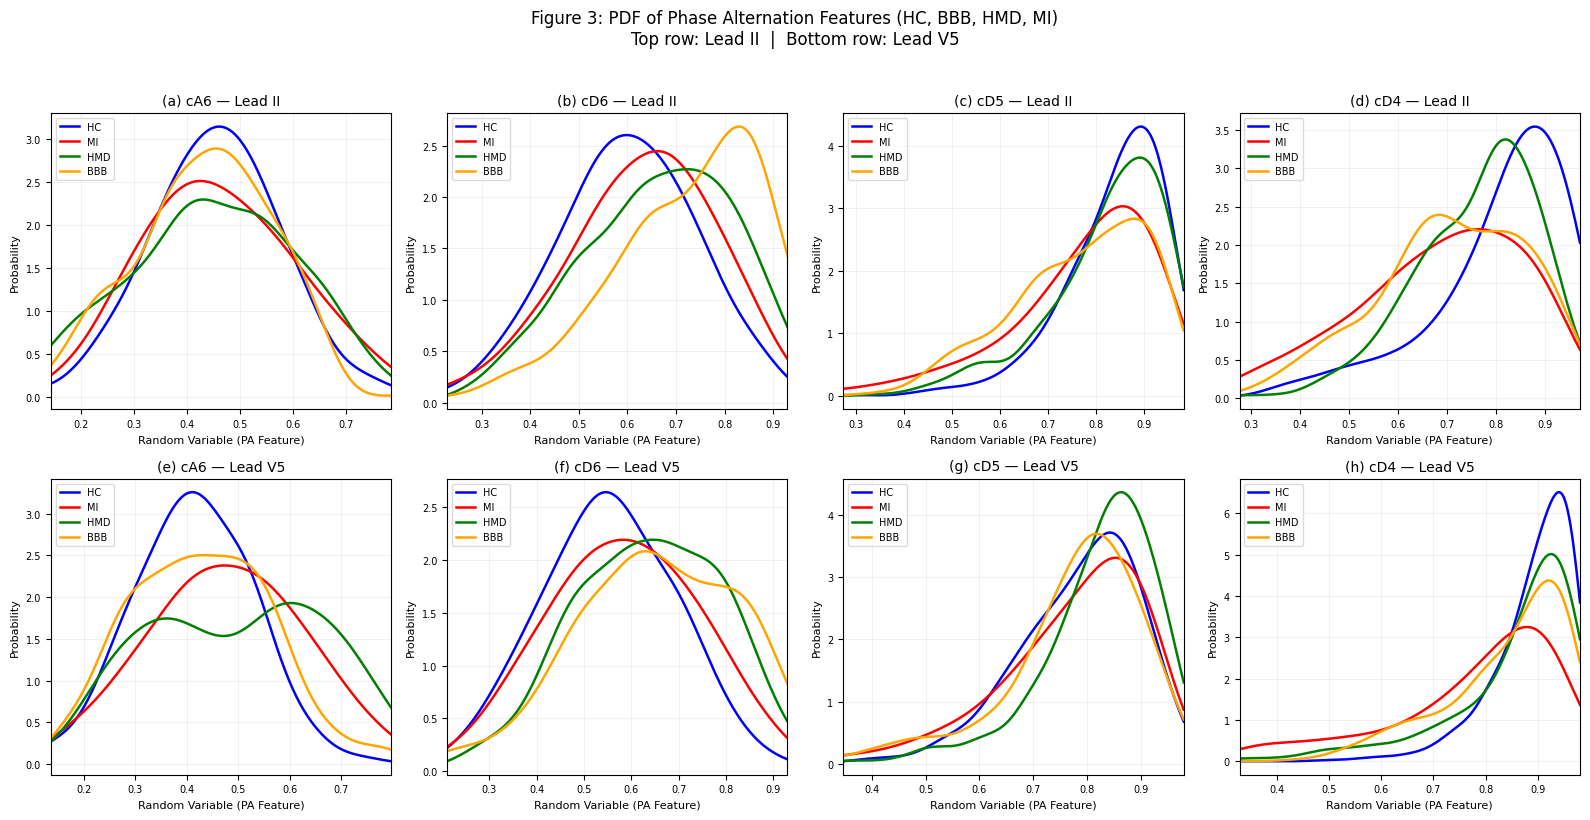

✓ Figure 3 saved as figure3_pdf_plots.png
✓ All results saved: table6_results.csv, sd_scores.npy, p_values.npy, X_anova.npy, X_sd.npy


In [30]:
# plotting the pdf of all the subband of lead II and V5

LEAD_II  = 1   # index in 12-lead array
LEAD_V5  = 10
COLORS   = {1:"blue", 2:"red", 3:"green", 4:"orange"}
CLS_NAME = {1:"HC",   2:"MI",  3:"HMD",   4:"BBB"}

fig = plt.figure(figsize=(16, 8))
fig.suptitle(
    "Figure 3: PDF of Phase Alternation Features (HC, BBB, HMD, MI)\n"
    "Top row: Lead II  |  Bottom row: Lead V5",
    fontsize=12, y=1.02
)

# Letter labels as in paper: (a)–(d) Lead II, (e)–(h) Lead V5
LETTERS = [['(a)','(b)','(c)','(d)'], ['(e)','(f)','(g)','(h)']]
lead_pairs = [(LEAD_II, "Lead II"), (LEAD_V5, "Lead V5")]

axes = fig.subplots(2, 4)

for row_i, (lead_idx, lead_name) in enumerate(lead_pairs):
    for col_i, (sb_idx, sb_name) in enumerate(enumerate(SUBBANDS)):
        ax = axes[row_i, col_i]
        feat_idx = lead_idx * 4 + sb_idx

        # Shared x range: 1st–99th percentile of all classes combined
        all_vals = X_scaled[:, feat_idx]
        x_lo = max(0.0, float(np.percentile(all_vals,  1)))
        x_hi = min(1.0, float(np.percentile(all_vals, 99)))
        x_range = np.linspace(x_lo, x_hi, 250)

        for cls_int in [1, 2, 3, 4]:
            vals = X_scaled[y_int == cls_int, feat_idx]
            if len(vals) > 3:
                kde = gaussian_kde(vals, bw_method=0.3)
                ax.plot(x_range, kde(x_range),
                        label=CLS_NAME[cls_int],
                        color=COLORS[cls_int],
                        linewidth=1.8)

        letter = LETTERS[row_i][col_i]
        ax.set_title(f"{letter} {sb_name} — {lead_name}", fontsize=10)
        ax.set_xlabel("Random Variable (PA Feature)", fontsize=8)
        ax.set_ylabel("Probability", fontsize=8)
        ax.legend(fontsize=7, loc='upper left', framealpha=0.7)
        ax.grid(True, alpha=0.25, linewidth=0.5)
        ax.set_xlim(x_lo, x_hi)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("figure3_pdf_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved as figure3_pdf_plots.png")


# 8. Save all outputs for later use
df_t6.to_csv("table6_results.csv", index=False)
np.save("sd_scores.npy",    sd_scores)
np.save("p_values.npy",     p_values)
np.save("X_anova.npy",      X_anova)
np.save("X_sd.npy",         X_sd)
np.save("sel_anova_idx.npy", sel_anova)
np.save("sel_sd_idx.npy",    sel_sd)
print("✓ All results saved: table6_results.csv, sd_scores.npy, p_values.npy, X_anova.npy, X_sd.npy")

# Visualization of Lead V6 ECG and Wavelet-Based Phase Features for Four Cardiac Conditions

Selected example records:
{'HC': '/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0/patient185/s0336lre', 'BBB': '/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0/patient225/s0448_re', 'HMD': '/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0/patient262/s0498_re', 'MI': '/kaggle/input/datasets/faisalziyadahmed/ptb-ecg-dataset/ptb-diagnostic-ecg-database-1.0.0/patient007/s0026lre'}


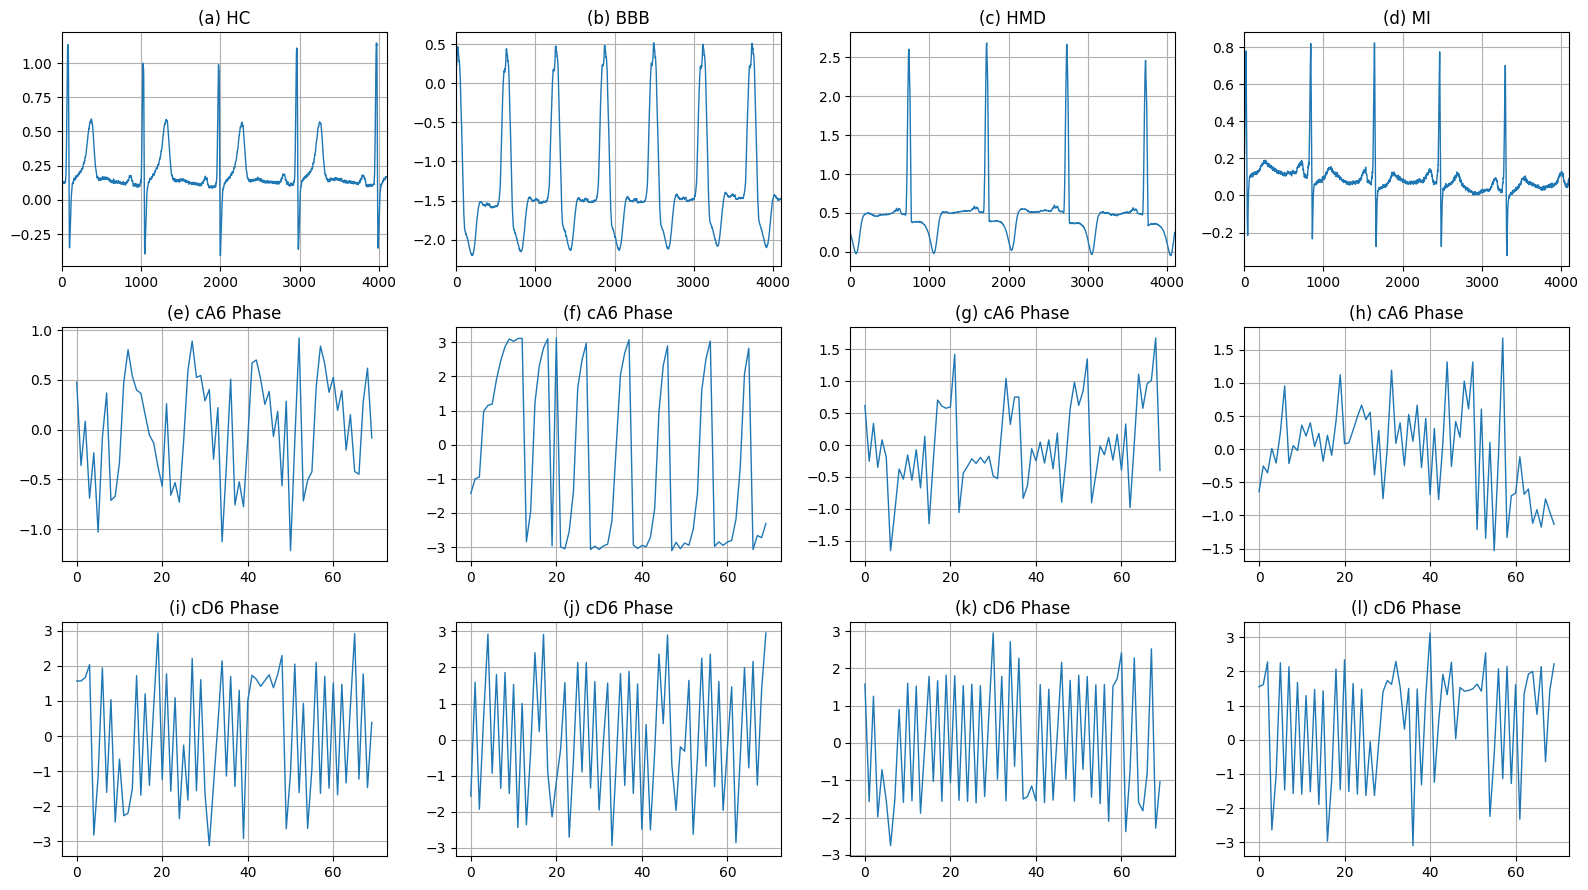

In [31]:
# 1. Select ONE record from each class

example_records = {}

for cls in ["HC", "BBB", "HMD", "MI"]:
    record_path = df_records[df_records["label"] == cls].iloc[0]["record_path"]
    example_records[cls] = record_path

print("Selected example records:")
print(example_records)


# 2. Function to extract lead V6 and DWT phase

def extract_v6_and_phase(record_path):
    
    rec = wfdb.rdrecord(record_path)
    signal = rec.p_signal
    fs = rec.fs
    
    # Lead V6 = index 11
    lead_v6 = signal[:, 11]
    
    # Use first 4096 samples (like paper)
    lead_v6 = lead_v6[:4096]
    
    # 6-level DWT
    coeffs = pywt.wavedec(lead_v6, 'db4', level=6)
    
    cA6 = coeffs[0]
    cD6 = coeffs[1]
    
    # Compute phase using Hilbert
    phase_cA6 = np.angle(hilbert(cA6))
    phase_cD6 = np.angle(hilbert(cD6))
    
    return lead_v6, phase_cA6, phase_cD6


# 3. Extract data for all 4 classes

data = {}

for cls, path in example_records.items():
    raw, phase_A6, phase_D6 = extract_v6_and_phase(path)
    data[cls] = {
        "raw": raw,
        "phase_A6": phase_A6,
        "phase_D6": phase_D6
    }


# 4. Plot EXACT Figure Layout (3 rows × 4 columns)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))

classes = ["HC", "BBB", "HMD", "MI"]

# -------- Row 1: Raw ECG --------
for i, cls in enumerate(classes):
    axes[0, i].plot(data[cls]["raw"], linewidth=1)
    axes[0, i].set_title(f"({chr(97+i)}) {cls}")
    axes[0, i].set_xlim(0, 4096)
    axes[0, i].grid(True)

# -------- Row 2: cA6 Phase --------
for i, cls in enumerate(classes):
    axes[1, i].plot(data[cls]["phase_A6"], linewidth=1)
    axes[1, i].set_title(f"({chr(101+i)}) cA6 Phase")
    axes[1, i].grid(True)

# -------- Row 3: cD6 Phase --------
for i, cls in enumerate(classes):
    axes[2, i].plot(data[cls]["phase_D6"], linewidth=1)
    axes[2, i].set_title(f"({chr(105+i)}) cD6 Phase")
    axes[2, i].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix


Generating confusion matrices for best configuration…


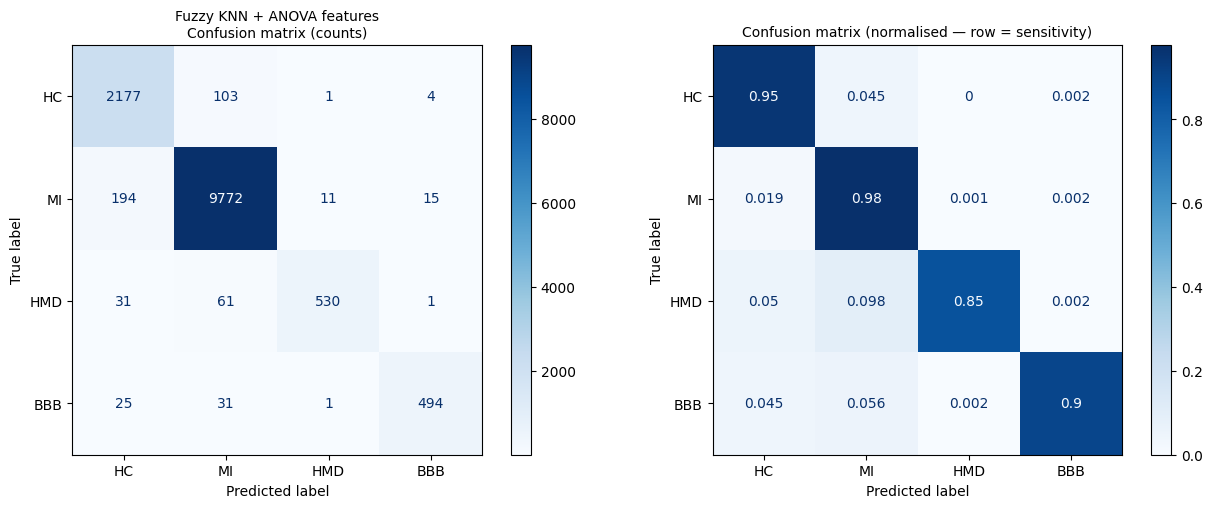

║    confusion_matrices.png  final CM                         ║


In [32]:

print("\nGenerating confusion matrices for best configuration…")

kf         = KFold(n_splits=5, shuffle=True, random_state=42)
cls_labels = [1, 2, 3, 4]
cls_names  = ["HC", "MI", "HMD", "BBB"]
CM_total   = np.zeros((4, 4), dtype=int)

for tr_idx, te_idx in kf.split(X_anova):
    X_tr, X_te = X_anova[tr_idx], X_anova[te_idx]
    y_tr, y_te = y_int[tr_idx],   y_int[te_idx]
    clf = FuzzyKNN(k=5)
    clf.fit(X_tr, y_tr)
    CM_total += confusion_matrix(y_te, clf.predict(X_te), labels=cls_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
disp0 = ConfusionMatrixDisplay(confusion_matrix=CM_total,
                                display_labels=cls_names)
disp0.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title("Fuzzy KNN + ANOVA features\nConfusion matrix (counts)", fontsize=10)

# Normalised (sensitivity per cell)
with np.errstate(divide='ignore', invalid='ignore'):
    CM_norm = CM_total.astype(float) / CM_total.sum(axis=1, keepdims=True)
disp1 = ConfusionMatrixDisplay(confusion_matrix=np.round(CM_norm, 3),
                                display_labels=cls_names)
disp1.plot(ax=axes[1], colorbar=True, cmap='Blues')
axes[1].set_title("Confusion matrix (normalised — row = sensitivity)", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("║    confusion_matrices.png  final CM                         ║")